# Car Price Prediction with Machine Learning

## Objective

Build a machine learning regression model to predict the selling price of used cars based on features such as car brand, car age, mileage, fuel type, seller type, and transmission.

## 1. Import Libraries

In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [55]:
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [56]:
df = pd.read_csv("car_data.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [57]:
df.shape

(4340, 8)

In [58]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [60]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [61]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(763)

In [63]:
df.duplicated().sum()

np.int64(763)

In [64]:
df = df.drop_duplicates().reset_index(drop=True)

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [67]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [68]:
categorical_columns = df.select_dtypes(include="str").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [69]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [70]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 3577
Number of columns: 8


In [71]:
print(df.columns.tolist())

['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


In [72]:
print("Column names:")
print(df.columns.tolist())

Column names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


## 3. Data Understanding

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3577 entries, 0 to 3576
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           3577 non-null   str  
 1   year           3577 non-null   int64
 2   selling_price  3577 non-null   int64
 3   km_driven      3577 non-null   int64
 4   fuel           3577 non-null   str  
 5   seller_type    3577 non-null   str  
 6   transmission   3577 non-null   str  
 7   owner          3577 non-null   str  
dtypes: int64(3), str(5)
memory usage: 223.7 KB


In [74]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [75]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Initial Data Inspection

The dataset contains information about used cars, including car name, manufacturing year, selling price, kilometres driven, fuel type, seller type, transmission type, and ownership history.

The dataset was inspected for its dimensions, column names, data types, missing values, and duplicate records before performing further data preprocessing.

In [76]:
df["fuel"]

0       Petrol
1       Petrol
2       Diesel
3       Petrol
4       Diesel
         ...  
3572    Diesel
3573    Diesel
3574    Petrol
3575    Diesel
3576    Petrol
Name: fuel, Length: 3577, dtype: str

## 4. Data Cleaning

In [77]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [78]:
print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 0
Duplicate rows after removal: 0


In [79]:
categorical_columns = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip().str.title()

In [80]:
print("Fuel types:")
print(df["fuel"].unique())

print("\nSeller types:")
print(df["seller_type"].unique())

print("\nTransmission types:")
print(df["transmission"].unique())

print("\nOwner types:")
print(df["owner"].unique())

Fuel types:
<StringArray>
['Petrol', 'Diesel', 'Cng', 'Lpg', 'Electric']
Length: 5, dtype: str

Seller types:
<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

Transmission types:
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

Owner types:
<StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str


## 5. Feature Engineering

In [81]:
current_year = 2026

df["car_age"] = current_year - df["year"]

In [82]:
df[["year", "car_age"]].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [83]:
df["brand"] = df["name"].str.split().str[0]

In [84]:
df[["name", "brand"]].head()

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda


In [85]:
df[["name", "brand", "year", "car_age"]].head()

,name,brand,year,car_age
0,Maruti 800 AC,Maruti,2007,19
1,Maruti Wagon R LXI Minor,Maruti,2007,19
2,Hyundai Verna 1.6 SX,Hyundai,2012,14
3,Datsun RediGO T Option,Datsun,2017,9
4,Honda Amaze VX i-DTEC,Honda,2014,12


## 6. Exploratory Data Analysis

### 6.1 Distribution of Selling Prices

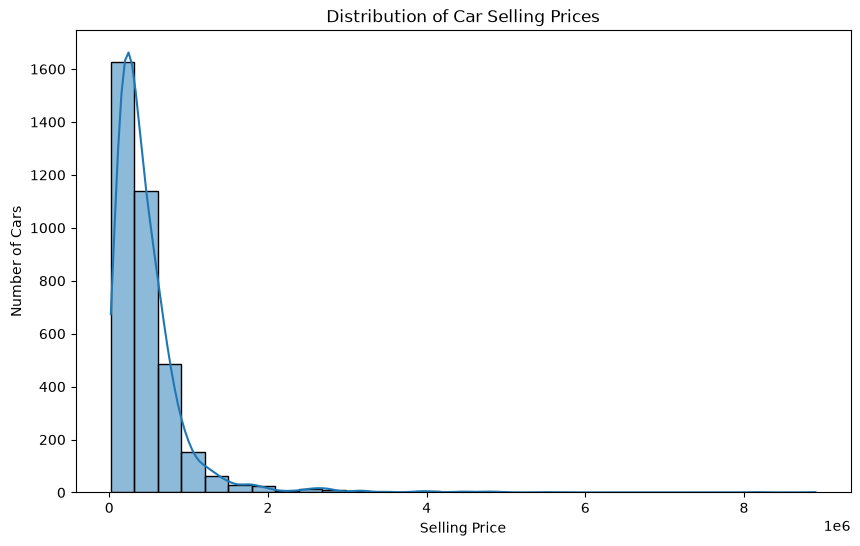

In [86]:
plt.figure(figsize=(10, 6))

sns.histplot(df["selling_price"], bins=30, kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

### Observation

The distribution of car selling prices is strongly right-skewed. Most cars in the dataset have relatively low selling prices, while the number of cars decreases as the selling price increases. A small number of cars have very high selling prices, which appear as potential outliers in the dataset.

### 6.2 Selling Price vs Fuel Type

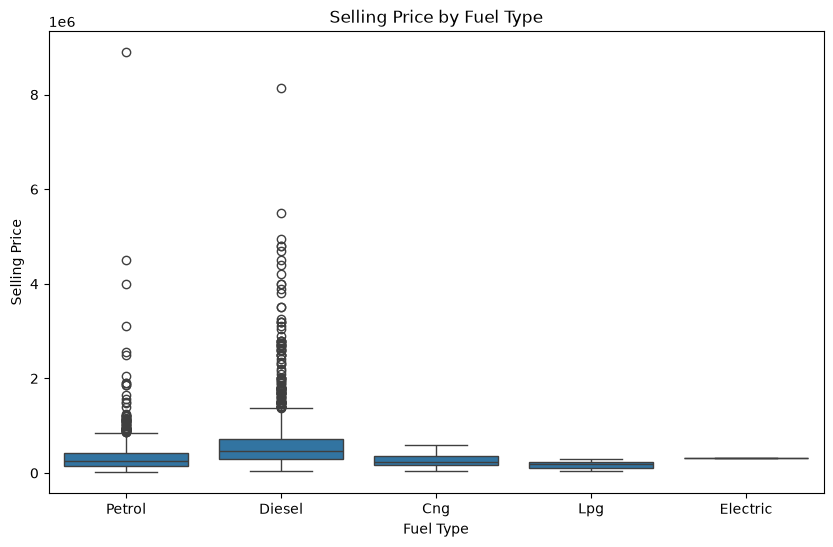

In [87]:
plt.figure(figsize=(10, 6))

sns.boxplot(x="fuel", y="selling_price", data=df)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

### Observation

The box plot shows that selling prices vary across different fuel types. Diesel cars have a higher median selling price compared with most other fuel categories and also contain several high-priced outliers. Petrol cars show a wider range of selling prices with many outliers. CNG and LPG cars generally have lower selling prices, while the electric category has very few observations, so strong conclusions cannot be drawn for electric cars.

### 6.3 Selling Price vs Car Age

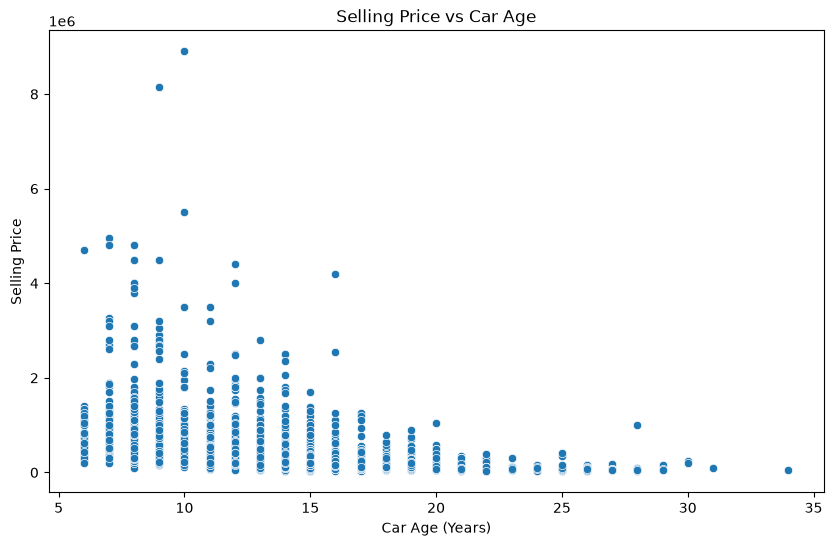

In [88]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x="car_age", y="selling_price", data=df)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")

plt.show()

### Observation

The scatter plot indicates a general negative relationship between car age and selling price. Newer cars tend to have higher selling prices, while older cars generally have lower selling prices. However, the relationship is not perfectly linear because selling price is also influenced by factors such as brand, mileage, fuel type, transmission, and ownership.

## 7. Data Preparation for Machine Learning

In [89]:
features = [
    "brand",
    "car_age",
    "km_driven",
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

target = "selling_price"

X = df[features]
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['brand', 'car_age', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

Target:
selling_price


In [90]:
X.head()

,brand,car_age,km_driven,fuel,seller_type,transmission,owner
0,Maruti,19,70000,Petrol,Individual,Manual,First Owner
1,Maruti,19,50000,Petrol,Individual,Manual,First Owner
2,Hyundai,14,100000,Diesel,Individual,Manual,First Owner
3,Datsun,9,46000,Petrol,Individual,Manual,First Owner
4,Honda,12,141000,Diesel,Individual,Manual,Second Owner


### Identifying Numerical and Categorical Features

The dataset contains both numerical and categorical features. Numerical features can be used directly by machine learning models, while categorical features need to be converted into numerical values using one-hot encoding.

In [91]:
numerical_features = [
    "car_age",
    "km_driven"
]

categorical_features = [
    "brand",
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['car_age', 'km_driven']
Categorical features: ['brand', 'fuel', 'seller_type', 'transmission', 'owner']


### Encoding Categorical Variables

One-hot encoding is used to convert categorical variables into numerical features. Each category is represented by a separate binary column, allowing machine learning regression models to process categorical information.

In [92]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

## 8. Feature Correlation Analysis

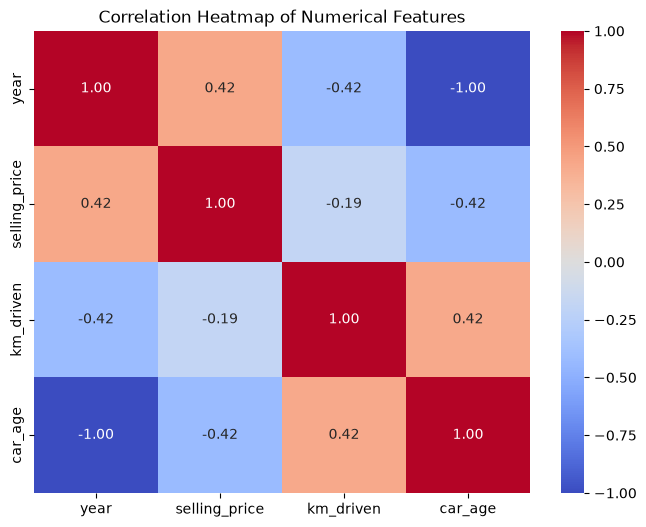

In [93]:
correlation_data = df[
    ["year", "selling_price", "km_driven", "car_age"]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Observation

The correlation heatmap shows the linear relationships among the numerical features. Car age has a negative relationship with selling price, indicating that older cars generally tend to have lower selling prices. Year and car age have a strong negative correlation because newer manufacturing years correspond to lower car ages. Kilometres driven also shows a relationship with selling price, although the relationship is weaker compared with the relationship between year and car age.

## 9. Train-Test Split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2861, 7)
Testing data: (716, 7)


## 10. Model Training

### 10.1 Linear Regression

In [95]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### Linear Regression Predictions

In [96]:
y_pred_linear = linear_model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred_linear[:10])

First 10 predicted prices:
[ 463870.75614059  473184.76537917  802478.71650183 1672437.5566109
  106461.30007816  378456.59600405  130884.23281308  671932.80793796
  821945.84585701  368765.67153425]


### 10.2 Random Forest Regressor

In [97]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Random Forest Predictions

In [98]:
y_pred_rf = random_forest_model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred_rf[:10])

First 10 predicted prices:
[ 578831.64772727  468797.90766667 1467164.909      2560066.65666667
  240886.66666667  348873.995       184079.16666667  663480.935
  877605.0902381   470535.        ]


## 11. Model Evaluation

### Evaluation Metrics

The trained regression models are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. Lower MAE and RMSE indicate smaller prediction errors, while a higher R² score indicates better model performance.

In [99]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
------------------
MAE : 206368.4021088282
RMSE: 431734.10288916324
R²  : 0.4213752379419863


In [100]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regressor
------------------------
MAE : 158267.51503646167
RMSE: 363457.658479879
R²  : 0.589916822759854


### Model Performance Comparison

In [101]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R² Score": [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,206368.402109,431734.102889,0.421375
1,Random Forest Regressor,158267.515036,363457.658480,0.589917


## 12. Feature Importance

### Feature Importance of Random Forest Regressor

Feature importance shows how much each input feature contributes to the predictions made by the Random Forest model. Higher importance values indicate features that have a greater influence on the predicted selling price.

In [102]:
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

importances = random_forest_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
41,remainder__car_age,0.221403
42,remainder__km_driven,0.135138
34,categorical__transmission_Automatic,0.125505
35,categorical__transmission_Manual,0.122073
28,categorical__fuel_Diesel,0.074373
1,categorical__brand_Audi,0.048357
30,categorical__fuel_Petrol,0.041013
13,categorical__brand_Land,0.040003
24,categorical__brand_Toyota,0.036876
2,categorical__brand_BMW,0.014460


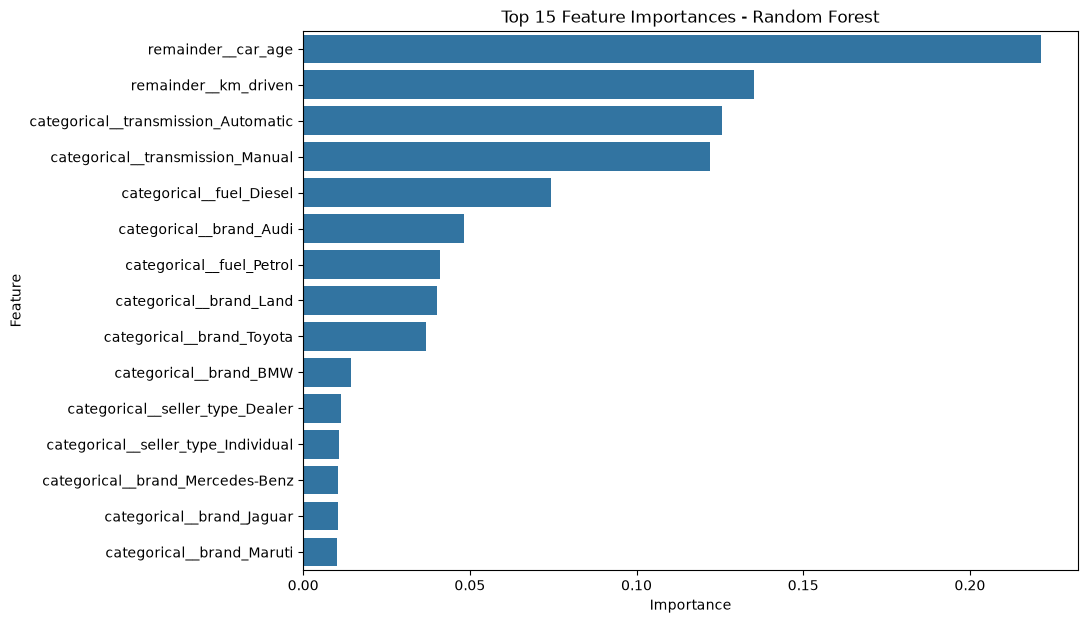

In [103]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Observation

The feature importance chart shows that car age is the most influential feature in the Random Forest model, followed by kilometres driven. Transmission type and fuel type also contribute significantly to the prediction of selling price. Several car brands, including Audi, Land Rover, Toyota, BMW, Mercedes-Benz, Jaguar, and Maruti, also contribute to the model's predictions. These importance values represent the relative contribution of each encoded feature and do not indicate whether the feature increases or decreases the selling price.

## 13. Actual vs Predicted Prices


### Random Forest: Actual vs Predicted Selling Prices

The scatter plot compares the actual selling prices from the test dataset with the prices predicted by the Random Forest model. Points closer to the diagonal reference line indicate more accurate predictions.

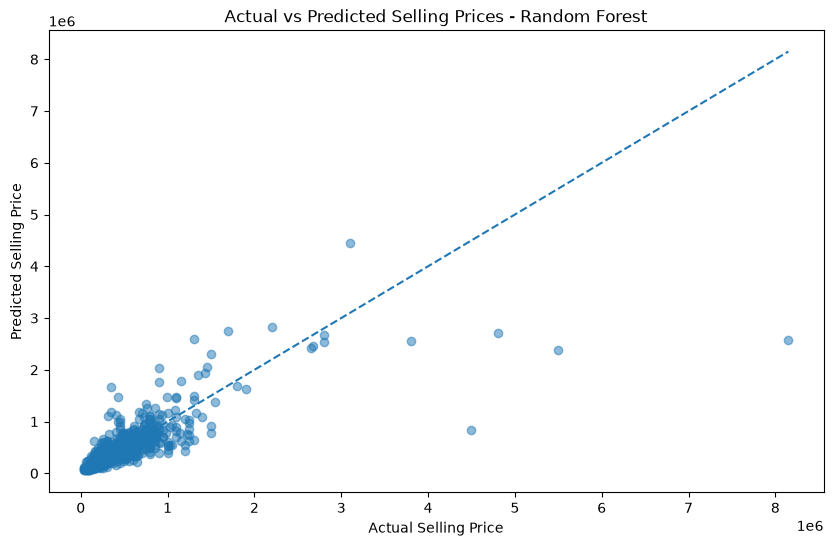

In [104]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Prices - Random Forest")

# Reference line
min_price = min(y_test.min(), y_pred_rf.min())
max_price = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.show()

### Observation

The actual versus predicted plot shows that many predictions are reasonably close to the diagonal reference line, indicating that the Random Forest model captures the general relationship between the input features and selling price. However, the model underestimates the prices of several high-priced cars, resulting in larger prediction errors for some expensive vehicles. This is consistent with the model's R² score of approximately 0.59.

## 14. Final Model Comparison

### Best Performing Model

Based on the evaluation metrics, the Random Forest Regressor performed better than Linear Regression. It achieved a lower MAE and RMSE and a higher R² score on the test dataset.

The Random Forest Regressor achieved an MAE of approximately ₹158,268, an RMSE of approximately ₹363,458, and an R² score of approximately 0.590. Therefore, Random Forest was selected as the best-performing model for this car price prediction task.


## 15. Conclusion

This project developed a machine learning model to predict used-car selling prices using features such as car brand, car age, kilometres driven, fuel type, seller type, transmission, and ownership.

The dataset was cleaned by handling duplicate records and standardizing categorical values. Feature engineering was performed by calculating car age from the manufacturing year and extracting the car brand from the car name.

Exploratory data analysis showed that car prices are strongly right-skewed, with most cars concentrated in the lower-to-mid price range. The analysis also showed that newer cars generally have higher selling prices, while older cars tend to have lower prices.

Two regression models, Linear Regression and Random Forest Regressor, were trained and evaluated using MAE, RMSE, and R² score. Random Forest performed better than Linear Regression, achieving an R² score of approximately 0.59.

The feature importance analysis showed that car age and kilometres driven were among the most influential features in the Random Forest model. Overall, the project demonstrates how machine learning can be used to estimate used-car selling prices based on vehicle characteristics.